In [1]:
import os
import sys
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [2]:
# Change the working directory to the following directory
parent_dir = "/home/agirmen/Github/ColibriPipeline-Tony-s-Version"
os.chdir(parent_dir)
sys.path.append(parent_dir)

# Getting the data

In [3]:
data_loc = "/home/agirmen/research_data/Sensitivity_Measurements_20240829"
framerates = ["100ms"]
dates = ["20240829"]


records = []
for fr in framerates:
    for dt in dates:
        search_path = os.path.join(data_loc, fr, dt, "*")
        for meas_folder in glob.glob(search_path):
            if os.path.isdir(meas_folder):
                records.append({
                    "framerate": fr,
                    "date": dt,
                    "measurement_path": meas_folder
                })

df_measurements = pd.DataFrame(records)
print(df_measurements.head())

  framerate      date                                   measurement_path
0     100ms  20240829  /home/agirmen/research_data/Sensitivity_Measur...
1     100ms  20240829  /home/agirmen/research_data/Sensitivity_Measur...
2     100ms  20240829  /home/agirmen/research_data/Sensitivity_Measur...
3     100ms  20240829  /home/agirmen/research_data/Sensitivity_Measur...
4     100ms  20240829  /home/agirmen/research_data/Sensitivity_Measur...


## Reducing a Single Minute and Airmass

getting the rcd filepaths:

In [6]:
# Pick the first folder of data for demonstration
data_test = df_measurements.iloc[0]
print(f"Processing data from: {data_test['measurement_path']}")

# Get all of the filepaths for all of the files within the measurement folder
filepaths = glob.glob(os.path.join(data_test['measurement_path'], "*.rcd"))

# Sort the filepaths
filepaths.sort()

# print the first 10 filepaths
print("First ten filepaths found:")
for filepath in filepaths[:10]:
    print(filepath)

num_frames = len(filepaths)
print(f"Total number of frames: {num_frames}")

Processing data from: /home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003
First ten filepaths found:
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000001.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000002.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000003.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000004.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000005.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.003/Alt89.2_100ms-_0000006.rcd
/home/agirmen/research_data/Sensitivity_Measurements_20240829/100ms/20240829/20240830_03.08.50.0

## load the images into memory

In [9]:
from ColibriPipeline.colibri_image_reader import importFramesRCD



img_array, img_times = importFramesRCD(filepaths, num_frames=num_frames) # Do it without darks first
print(f"Image array shape: {img_array.shape}")

Image array shape: (600, 2048, 2048)


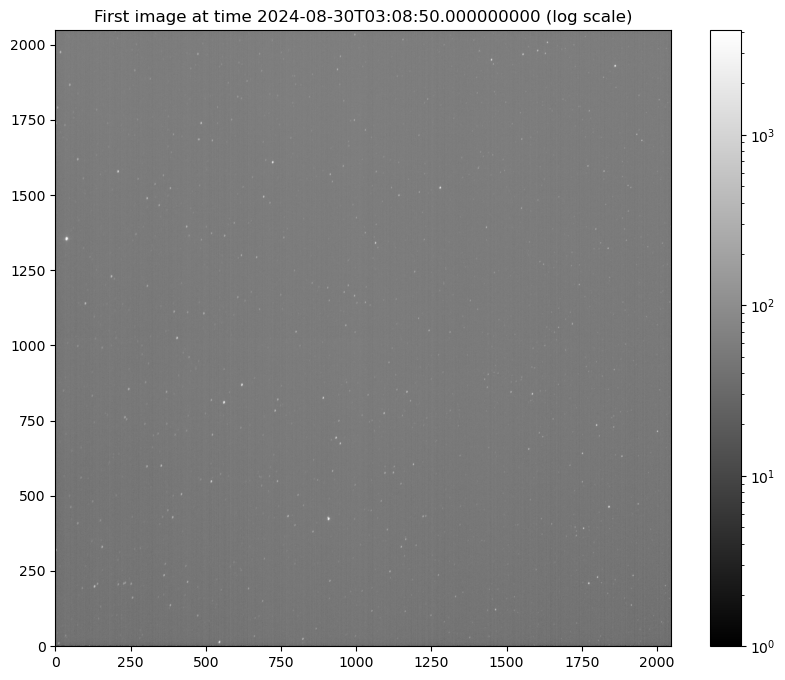

In [11]:
from matplotlib.colors import LogNorm

# Plot the first image with log scaling and larger figure size
plt.figure(figsize=(10, 8))
plt.imshow(img_array[0], cmap='gray', norm=LogNorm(), origin='lower')
plt.title(f"First image at time {img_times[0]} (log scale)")
plt.colorbar()
plt.show()